Empezamos cargando la tabla y haciendo un pequeño analisis exploratorio. Vamos a usar los datos de la tabla 5, ya que de momento no necesitamos más 

In [330]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

In [331]:
mt5 = pd.read_csv("../megatabla_5.tsv", sep="\t")


Queremos quedarnos con genes "de calidad" para medir la degradación. Queremos garantizar que en estos no suceda el problema de los ISMs por degradación, que se degraden (o por lo menos que la diferencia a la TSS no aumente a medida que empeora la calidad del RNA), que tengan un conteo aceptable (yo creo que como no estamos analizando expresión diferencial y simplemente queremos "saber que está suficientemente respaldado" no hace falta normalizar por profundidad asi que usaremos los counts) y que estén bien asignadas
El primer paso es cargar la tabla, filtrarla para quedarnos con genes que solo tengan una isoforma y que aparezca en los classifications de todos los RINs. Tambien nos quitamos casos en los que la diff_to_TSS sea mas larga que la longitud del transcrito de referencia. Nos quitamos también casos con diferencias a las TSS positivas muy grandes y en las que son pequeñas (pero positivas) las convertimos en 0.
Gestionar lo de los TS distintos. Yo creo que podemos intentar filtrar la tabla a solo los transcritos que aparezcan en todas las combinaciones de TS y RIN posibles. Una vez hecho esto, podemos intentar calcular las correlaciones entre TS. Si son suficientemente cercanas, podemos juntarlo todo para tener más puntos de RIN. En el caso de los que tienen mismo RIN exacto, habría que sacar una media. Mi idea ha sido hacer una regresion que se ajuste a nuestros datos en función del RIN y luego ajustar sumando lo que le falta a la mediana de cada muestra para estar en esta curva.

In [332]:
# Nos añadimos esta columna para luego
mt5["RIN_TS"] = mt5["RIN"].astype(str) + "_" + mt5["TS"]
# We filter to avoid dealing with monoexonic genes.
mt5_filt  = mt5[mt5["exon_junction_density"]>0]
# FILTER 1 ISOFORM
mt5_filt["num_isoformas"] = mt5_filt.groupby("associated_gene")["associated_transcript"].transform("nunique")
mt5_filt = mt5_filt[mt5_filt["num_isoformas"] == 1]

# FALTARIA, para cada grupo, colapsar diff_to_TSS a nivel gen con media ponderada y los counts tenerlos en cuenta.
mt5_filt["diff_to_gene_TSS"] = (mt5_filt.groupby(["associated_gene","RIN","TS"])["diff_to_gene_TSS"].transform(lambda s: np.average(s, weights=mt5_filt.loc[s.index, "counts"])))
# FILTRO TSS POSITIVA Nos quitamos los que tienen un diff_to_gene_TSS mayor que 100pb
# y pasamos los demas a 0
mt5_filt = mt5_filt[~(mt5_filt["diff_to_gene_TSS"] > 100)]
mt5_filt.loc[mt5_filt["diff_to_gene_TSS"] > 0, "diff_to_gene_TSS"] = 0

# COLUMNAS porcentaje
mt5_filt["porc_falt"] = abs(mt5_filt["diff_to_gene_TSS"]) / mt5_filt["ref_length"]
mt5_filt = mt5_filt[mt5_filt["porc_falt"] <= 1]
mt5_filt["porc_cubierto"] = 1 - mt5_filt["porc_falt"]
mt5_filt = mt5_filt.drop_duplicates(["RIN","TS","associated_gene"])
# FILTER to make sure we use genes that are in all of the samples
rin_ts_combs = mt5_filt[["RIN","TS"]].drop_duplicates()
n_combs = mt5_filt.drop_duplicates(["associated_gene", "RIN", "TS"]).groupby("associated_gene").size()
mt5_filt["n_combs"] = mt5_filt["associated_gene"].map(n_combs)
n_combs_max = mt5_filt["n_combs"].max()
mt5_filt = mt5_filt[mt5_filt["n_combs"] == n_combs_max]


C:\Users\Andres\AppData\Local\Temp\ipykernel_14412\1394507016.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mt5_filt["num_isoformas"] = mt5_filt.groupby("associated_gene")["associated_transcript"].transform("nunique")


Un tema que interesa entender es si en estos genes que hemos sacado hay una distribucion similar de las diferencias al TSS entre TS (y idealmente entre RINs). 

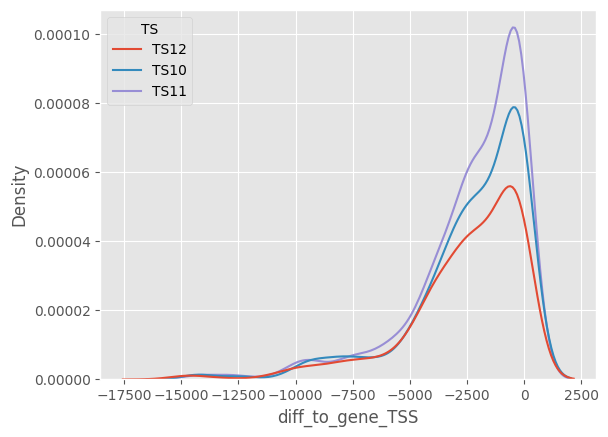

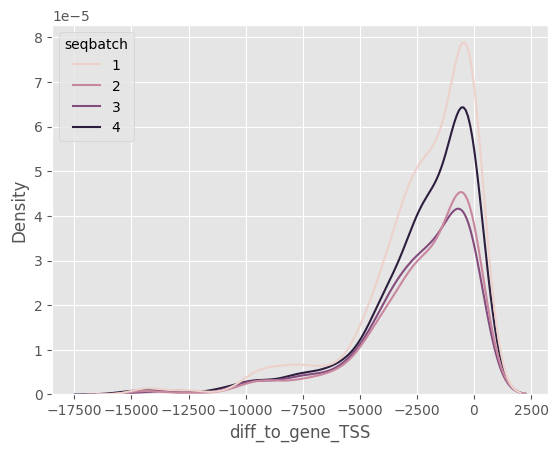

<Axes: xlabel='diff_to_gene_TSS', ylabel='Density'>

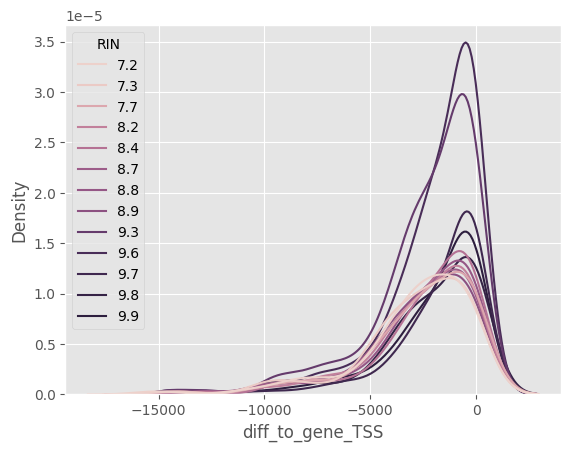

In [333]:
mt5_filt = mt5_filt.sort_values(by="RIN")
sns.kdeplot(mt5_filt,x="diff_to_gene_TSS",hue="TS")
plt.show()
sns.kdeplot(mt5_filt,x="diff_to_gene_TSS",hue="seqbatch")
plt.show()
sns.kdeplot(mt5_filt,x="diff_to_gene_TSS",hue="RIN")

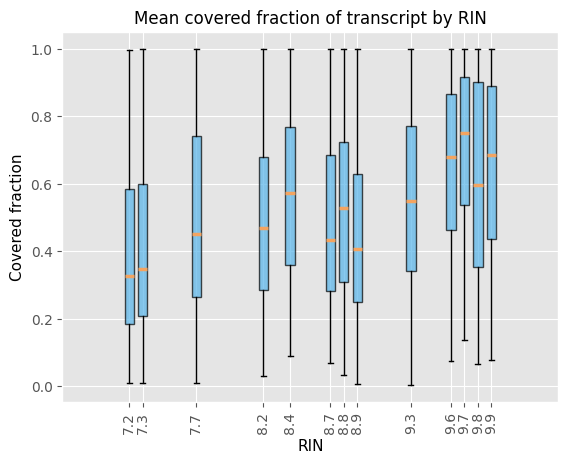

In [334]:
groups = [g["porc_cubierto"].values for _, g in mt5_filt.groupby("RIN")]
positions = sorted(mt5_filt["RIN"].unique())
plt.style.use("ggplot")
fig, ax = plt.subplots()

bp = ax.boxplot(
    groups,
    positions=positions,
    widths=0.07,
    patch_artist=True
)

for box in bp["boxes"]:
    box.set(facecolor="#56B4E9", alpha=0.7)
for median in bp["medians"]:
    median.set(color="sandybrown", linewidth=2.5)
ax.set_title(
    "Mean covered fraction of transcript by RIN",
    fontsize=12,      # tamaño del título
    color="black",
    fontweight="normal"
)
plt.xticks(rotation=90)
ax.set_xlabel(
    "RIN",
    fontsize=11,
    color="black"
)

ax.set_ylabel(
    "Covered fraction",
    fontsize=11,
    color="black"
)
plt.show()

YA NO LO HACEMOS
Esto es un poco más dificil de normalizar, ya que sabemos que a medida que aumenta el RIN la diff_to_TSS no se deberia mantener constante. Una cosa chula seria ajustar una recta entre las medias/medianas en funcion del RIN y restarle a los valores lo que se desvia la mediana de la media de lo que predice la recta.

mt5_filt["median_porc_cubierto"] = mt5_filt.groupby("RIN_TS")["porc_cubierto"].transform("median")
tabla_reg = mt5_filt[["RIN_TS","RIN","median_porc_cubierto"]].drop_duplicates()
tabla_reg = tabla_reg.drop(columns="RIN_TS")
reg = LinearRegression().fit(tabla_reg[["RIN"]], tabla_reg[["median_porc_cubierto"]])
reg_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
reg_poly.fit(tabla_reg[["RIN"]], tabla_reg["median_porc_cubierto"])
mt5_filt["median_porc_cubierto_pred"] = reg_poly.predict(mt5_filt[["RIN"]])
mt5_filt["dif_median"] = mt5_filt["median_porc_cubierto"].sub(mt5_filt["median_porc_cubierto_pred"])
mt5_filt["porc_cubierto_norm"] = mt5_filt["porc_cubierto"] - mt5_filt["dif_median"]
mt5_filt.head()

Realmente lo que tenemos que hacer es agrupar en función de la curva porcentaje vs RIN. Para eso vamos a hacer un pivote
en el que nos quede una columna por cada valor de RIN, una fila por associated gene/transcript y que los valores sean la columna porc

In [335]:
import matplotlib.pyplot as plt

mt5_pivot = mt5_filt.pivot_table(index="associated_gene", columns="RIN", values="porc_cubierto").reset_index()
print(len(mt5_pivot))
print(mt5_pivot.columns)
print(len(mt5_pivot))



170
Index(['associated_gene',               7.2,               7.3,
                     7.7,               8.2,               8.4,
                     8.7,               8.8,               8.9,
                     9.3,               9.6,               9.7,
                     9.8,               9.9],
      dtype='object', name='RIN')
170


Ahora hay que normalizar la tabla. No hay valores nulos y van del 0 al 1. Hacemos prácticamente un z_score por fila

In [336]:
mt5_normalized = mt5_pivot.copy()

cols_RIN = mt5_normalized.columns[1:]
mt5_normalized[cols_RIN] = mt5_normalized[cols_RIN].apply(lambda x: (x-x.mean()), axis=1) # / x.std() if x.std() != 0 else 0

mt5_normalized.head()


RIN,associated_gene,7.2,7.3,7.7,8.2,8.4,8.7,8.8,8.9,9.3,9.6,9.7,9.8,9.9
0,ENSG00000001629,-0.109905,-0.113085,-0.130103,-0.057032,0.104297,-0.112371,0.138086,-0.113215,0.022798,0.278872,0.152811,-0.012635,-0.048518
1,ENSG00000004478,-0.023447,-0.010294,0.005460,0.008913,-0.002617,-0.001194,-0.000308,-0.017602,-0.006850,0.006625,0.015045,0.014566,0.011703
2,ENSG00000007520,-0.535301,-0.226833,0.388303,-0.170931,0.031686,-0.063500,0.027255,-0.243064,-0.067004,0.091477,0.203914,0.383753,0.180247
3,ENSG00000034510,-0.112350,-0.104694,0.041080,0.000327,0.023765,0.008493,0.029606,-0.078137,0.001888,0.046178,0.062360,0.005388,0.076097
4,ENSG00000034713,-0.329667,-0.328715,-0.082672,-0.039400,-0.061524,0.006003,0.070116,-0.175580,0.023790,0.218424,0.314593,0.163281,0.221351


In [337]:
X = mt5_normalized.copy()
X = mt5_normalized.set_index("associated_gene")
X.head()


RIN,7.2,7.3,7.7,8.2,8.4,8.7,8.8,8.9,9.3,9.6,9.7,9.8,9.9
associated_gene,,,,,,,,,,,,,
ENSG00000001629,-0.109905,-0.113085,-0.130103,-0.057032,0.104297,-0.112371,0.138086,-0.113215,0.022798,0.278872,0.152811,-0.012635,-0.048518
ENSG00000004478,-0.023447,-0.010294,0.005460,0.008913,-0.002617,-0.001194,-0.000308,-0.017602,-0.006850,0.006625,0.015045,0.014566,0.011703
ENSG00000007520,-0.535301,-0.226833,0.388303,-0.170931,0.031686,-0.063500,0.027255,-0.243064,-0.067004,0.091477,0.203914,0.383753,0.180247
ENSG00000034510,-0.112350,-0.104694,0.041080,0.000327,0.023765,0.008493,0.029606,-0.078137,0.001888,0.046178,0.062360,0.005388,0.076097
ENSG00000034713,-0.329667,-0.328715,-0.082672,-0.039400,-0.061524,0.006003,0.070116,-0.175580,0.023790,0.218424,0.314593,0.163281,0.221351


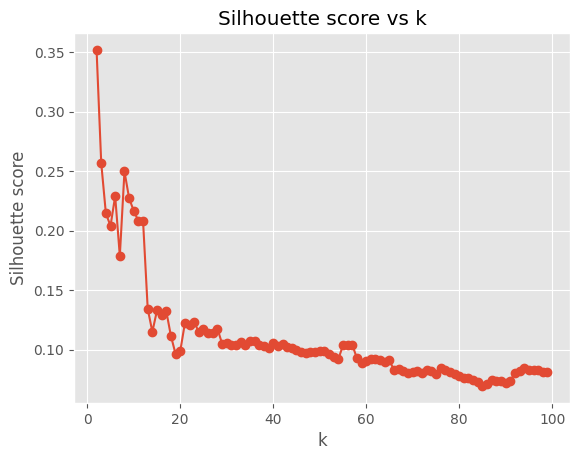

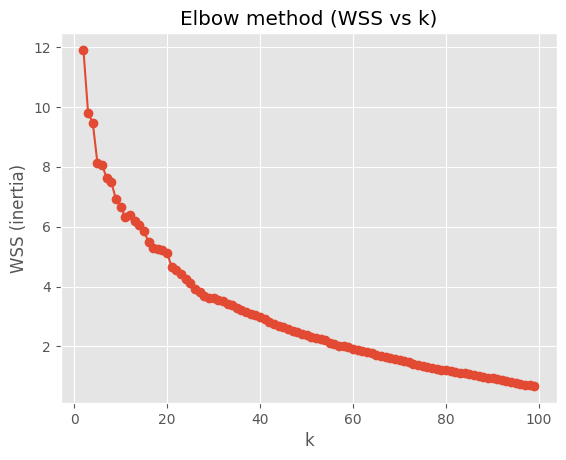

In [338]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sil_scores = []
K = range(2, 100)
wss = []
X.columns = [str(col) for col in X.columns]
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels = kmeans.fit_predict(X)
    # Para el elbow plot
    wss.append(kmeans.inertia_)
    # Para el silhouette score
    score = silhouette_score(X, labels)
    sil_scores.append(score)

# silhouette score plot
plt.figure()
plt.plot(K, sil_scores, marker='o')
plt.title("Silhouette score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.show()

#elbow plot
plt.figure()
plt.plot(K, wss, marker='o')
plt.title("Elbow method (WSS vs k)")
plt.xlabel("k")
plt.ylabel("WSS (inertia)")
plt.show()

Ahora vamos al kmeans con 9 clusters

In [339]:

k = 2
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init="auto"
)

clusters = kmeans.fit_predict(X)

X["cluster"] = clusters


In [358]:
import glob
import os
genes=X.index.tolist()
for i in glob.glob("../inputs_2/*"):
    tabla = pd.read_csv(i,sep="\t")
    print(i,len(tabla))
    tabla = tabla[tabla["associated_gene"].isin(genes)]
    print(len(tabla))
    tabla.to_csv(f"../classifications_filtrados/{os.path.basename(i)}_filt",sep="\t",index=False)

C:\Users\Andres\AppData\Local\Temp\ipykernel_14412\3186669614.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  tabla = pd.read_csv(i,sep="\t")


../inputs_2\TS10_RIN_7.7_pass_classification.txt 436271
4999


C:\Users\Andres\AppData\Local\Temp\ipykernel_14412\3186669614.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  tabla = pd.read_csv(i,sep="\t")


../inputs_2\TS10_RIN_8.4_pass_classification.txt 1640512
20371


C:\Users\Andres\AppData\Local\Temp\ipykernel_14412\3186669614.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  tabla = pd.read_csv(i,sep="\t")


...

../inputs_2\TS12_RIN_7.3_pass_classification.txt 1107626
10018


C:\Users\Andres\AppData\Local\Temp\ipykernel_14412\3186669614.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  tabla = pd.read_csv(i,sep="\t")


../inputs_2\TS12_RIN_8.2_pass_classification.txt 1718499
17467


C:\Users\Andres\AppData\Local\Temp\ipykernel_14412\3186669614.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  tabla = pd.read_csv(i,sep="\t")


../inputs_2\TS12_RIN_9.9_pass_classification.txt 890859
10665


In [ ]:
with open("../genes_clusters.txt","w") as f:
    for i in genes:
        f.write(i+"\n")
        


In [369]:
tusco = pd.read_csv("../tusco_human.tsv",sep="\t",header=None)
tusco_genes = tusco[0].tolist()
print(set(tusco_genes).intersection(set(genes)))

{'ENSG00000262664', 'ENSG00000127920', 'ENSG00000280789', 'ENSG00000188636', 'ENSG00000146066', 'ENSG00000182154'}


In [ ]:
tablita_tusco = X[X.index.isin(tusco_genes)]
tablita_tusco.head()
mt5_filt_tusco = mt5_filt[mt5_filt["associated_gene"].isin(tablita_tusco.index)]
mt5_filt_tusco.sort_values(by=["cluster","delta(diff_to_gene_TSS)"], ascending=False).drop_duplicates("associated_gene")

,length,structural_category,associated_gene,associated_transcript,ref_length,ref_exons,diff_to_gene_TSS,diff_to_gene_TTS,strand,covered_exons,...,CPM_transcript,clave,ratio_counts,delta(diff_to_gene_TSS),RIN_TS,num_isoformas,porc_falt,porc_cubierto,n_combs,cluster
313350,1033.589744,full-splice_match,ENSG00000280789,ENST00000320330,3874.0,3.0,-1223.482143,-2381.487179,+,3,...,16.358652,ENST00000320330_3full-splice_match,0.496225,228.468531,8.7_TS11,1,0.315819,0.684181,15,1
314023,973.705882,full-splice_match,ENSG00000262664,ENST00000572195,1031.0,2.0,-48.205882,-9.088235,+,2,...,9.932039,ENST00000572195_2full-splice_match,0.396556,14.997549,8.7_TS11,1,0.046756,0.953244,15,1
214587,562.288889,full-splice_match,ENSG00000182154,ENST00000371443,582.0,2.0,-190.437500,-2.577778,+,2,...,31.399988,ENST00000371443_2full-splice_match,0.442573,13.029932,7.2_TS12,1,0.327212,0.672788,15,1
334631,1111.681818,incomplete-splice_match,ENSG00000188636,ENST00000341255,5419.0,2.0,-4526.272727,-13.045455,-,1,...,7.010851,ENST00000341255_1incomplete-splice_match,0.373229,1302.818182,8.7_TS11,1,0.835260,0.164740,15,0
214197,602.250000,full-splice_match,ENSG00000127920,ENST00000248564,3019.0,2.0,-2498.455882,-2098.343750,+,2,...,22.241658,ENST00000248564_2full-splice_match,0.481913,75.937500,7.2_TS12,1,0.827577,0.172423,15,0
213597,611.853659,full-splice_match,ENSG00000146066,ENST00000274787,654.0,2.0,-278.242268,-4.772358,+,2,...,63.454143,ENST00000274787_2full-splice_match,0.414513,18.073284,7.2_TS12,1,0.425447,0.574553,15,0


C:\Users\Andres\AppData\Local\Temp\ipykernel_14412\2330377171.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


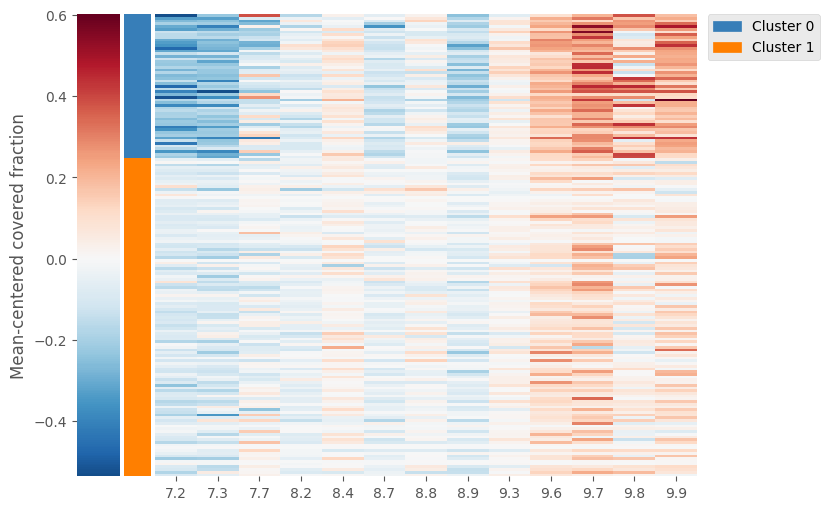

In [341]:

import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

df_heatmap = X.copy().sort_values('cluster')

data_to_plot = df_heatmap.drop('cluster', axis=1)


lut = {0: "#377eb8", 1: "#ff7f00"}
row_numbers = df_heatmap['cluster'].values.reshape(-1, 1)


fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(1, 3, width_ratios=[0.08, 0.05, 1], wspace=0.02)

ax_cbar = fig.add_subplot(gs[0])
ax_colors = fig.add_subplot(gs[1])
ax_heatmap = fig.add_subplot(gs[2])


sns.heatmap(
    data_to_plot, ax=ax_heatmap, cmap="RdBu_r", center=0,
    cbar_ax=ax_cbar, cbar_kws={'label': 'Mean-centered covered fraction', 'location': 'left'}
)
ax_cbar.yaxis.set_ticks_position('left')
ax_cbar.yaxis.set_label_position('left')

cmap_clusters = ListedColormap([lut[0], lut[1]])
sns.heatmap(
    row_numbers, ax=ax_colors, 
    cbar=False, xticklabels=False, yticklabels=False, 
    cmap=cmap_clusters
)

legend_patches = [mpatches.Patch(color=lut[i], label=f'Cluster {i}') for i in lut]
ax_heatmap.legend(handles=legend_patches, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

ax_heatmap.set_yticks([]) 
ax_heatmap.set_ylabel("")
plt.tight_layout()
plt.show()

In [342]:
df_heatmap.head(10)

,7.2,7.3,7.7,8.2,8.4,8.7,8.8,8.9,9.3,9.6,9.7,9.8,9.9,cluster
associated_gene,,,,,,,,,,,,,,
ENSG00000007520,-0.535301,-0.226833,0.388303,-0.170931,0.031686,-0.063500,0.027255,-0.243064,-0.067004,0.091477,0.203914,0.383753,0.180247,0
ENSG00000034713,-0.329667,-0.328715,-0.082672,-0.039400,-0.061524,0.006003,0.070116,-0.175580,0.023790,0.218424,0.314593,0.163281,0.221351,0
ENSG00000090470,-0.262207,-0.243465,-0.316104,0.066852,0.000215,-0.082330,0.133377,-0.075919,0.083757,0.156757,0.123907,0.265547,0.149612,0
ENSG00000084090,-0.195684,-0.210825,-0.258610,-0.039794,-0.018623,-0.208807,-0.025232,-0.188330,0.084940,0.198450,0.271225,0.248486,0.342805,0
ENSG00000089154,-0.303106,-0.403908,0.031768,-0.187871,-0.042481,-0.362031,-0.045201,-0.217980,-0.016749,0.235821,0.538280,0.284850,0.488607,0
ENSG00000108829,-0.329510,-0.289050,-0.219173,0.012501,0.113719,-0.075867,0.001635,-0.103645,0.058919,0.113373,0.293045,0.160549,0.263506,0
ENSG00000100030,-0.134640,-0.161341,-0.182113,-0.113962,-0.085471,-0.125512,-0.096078,-0.144571,0.136336,0.268026,0.557744,-0.021396,0.102978,0
ENSG00000091542,-0.159794,-0.205010,-0.195129,-0.054983,0.107003,-0.036851,-0.097526,-0.096105,0.025235,0.183351,0.280205,-0.109569,0.359175,0
ENSG00000108349,-0.159741,-0.160697,-0.134991,-0.030658,0.011050,-0.131326,-0.051103,-0.078932,-0.025036,0.176106,0.428659,-0.081514,0.238183,0


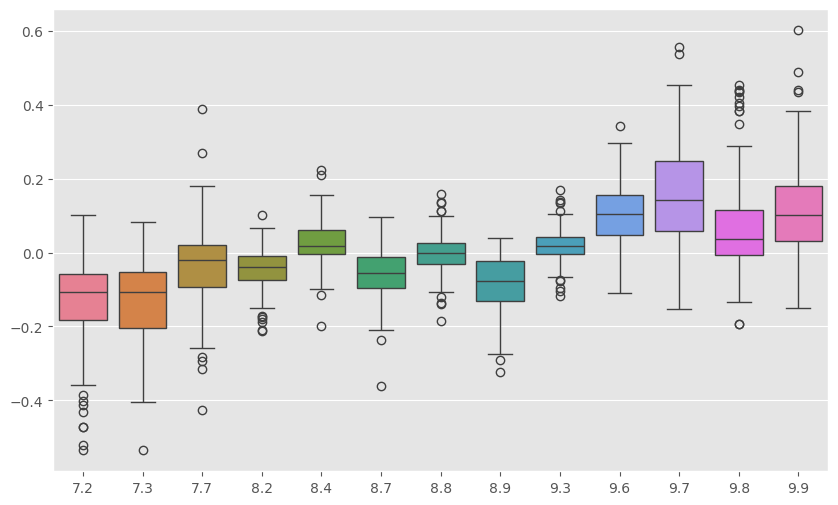

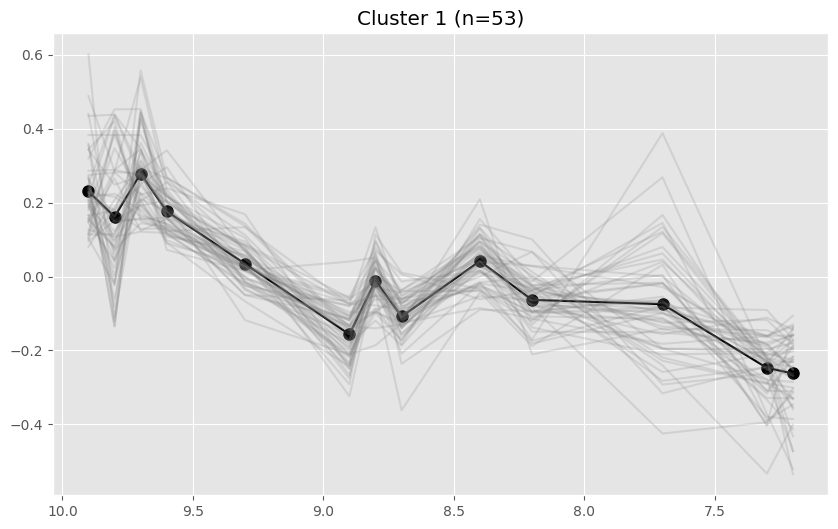

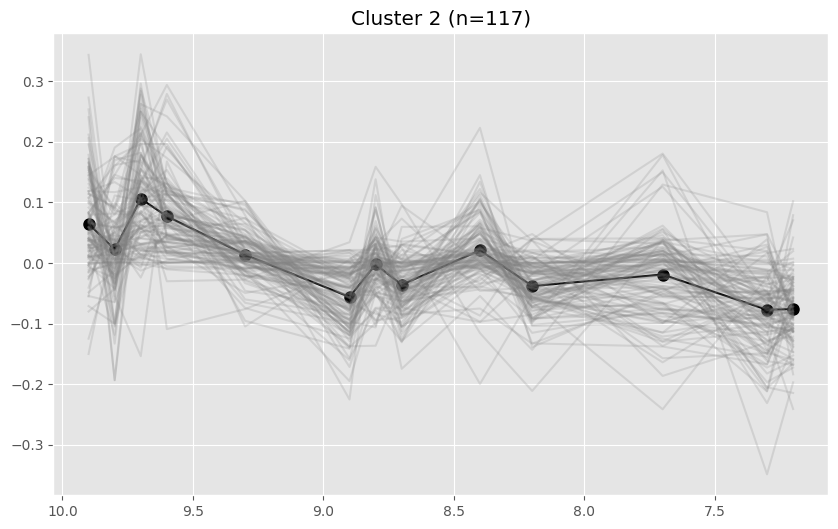

In [343]:
import seaborn as sns
rins = [col for col in X.columns if col != "cluster"]
rins_float = [float(col) for col in X.columns if col != "cluster"]
n = -1
medias_clusters = []
plt.figure(figsize=(10, 6))
sns.boxplot(X[rins])
for i in range(k):
    n += 1
    plt.figure(figsize=(10, 6))
    subset = X[X["cluster"] == i][rins]
    media_cluster = subset.mean()
    medias_clusters.append(media_cluster)
    plt.plot(rins_float, subset.mean(), color = "black", marker="o", markersize=8, label="Media del cluster")
    
    for i in subset.iterrows():
        plt.plot(rins_float, i[1], alpha = 0.2, color = "gray")
    plt.title(f"Cluster {n+1} (n={len(subset)})")
    # Ahora quiero poner el eje X al reves, con el RIN más alto a la derecha
    plt.gca().invert_xaxis()
    


Text(0.5, 1.0, 'Medias de cada cluster')

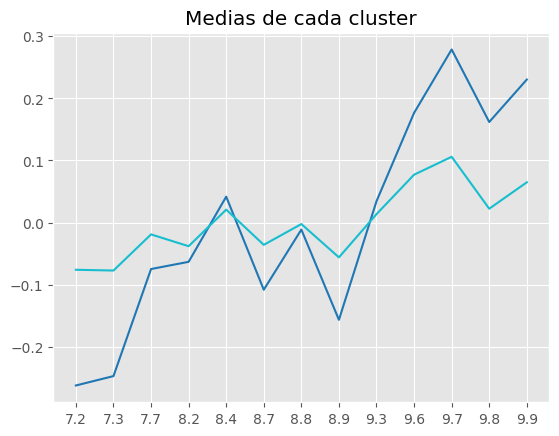

In [344]:
colors = plt.cm.tab10(np.linspace(0, 1, k))
for i in range(k):
    plt.plot(rins, medias_clusters[i], color = colors[i], markersize=8, label=f"Media del cluster {i+1}")
#plt.legend()
plt.title("Medias de cada cluster")

In [345]:
mt5_pivot_kmeans1 = mt5_pivot.copy()
mt5_pivot_kmeans1["cluster"] = clusters
mt5_pivot_kmeans1 = mt5_pivot_kmeans1.drop(columns=[8.8,9.8])

In [346]:
mt5_pivot_kmeans1 = mt5_pivot_kmeans1.set_index("associated_gene")


In [347]:

mt5_pivot_kmeans1.head()
mt5_filt["cluster"] = mt5_filt["associated_gene"].map(mt5_pivot_kmeans1["cluster"])
mt5_filt.to_csv("mt5_filtered_clusters.tsv", sep="\t", index=False)
print(len(mt5_filt))
print(mt5_filt["cluster"].isnull().sum())

2550
0


Text(0, 0.5, 'Density')

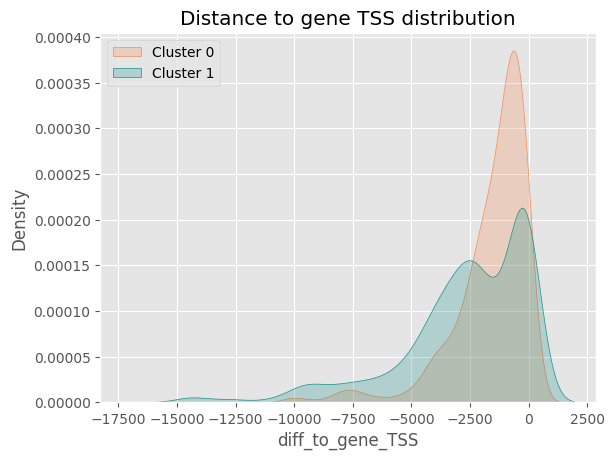

In [348]:
colores = ["#F58A53","#FDC659","#15918A"]

sns.kdeplot(mt5_filt[mt5_filt["cluster"] == 0.0], x="diff_to_gene_TSS", label="Cluster 0",color=colores[0],fill=True)
sns.kdeplot(mt5_filt[mt5_filt["cluster"] == 1.0], x="diff_to_gene_TSS", label="Cluster 1",color=colores[2],fill=True)  
plt.legend()
plt.title("Distance to gene TSS distribution")
plt.ylabel("Density")


[7.3, 7.7, 8.2, 8.4, 8.7, 8.9, 9.3, 9.6, 9.7, 9.9]
2


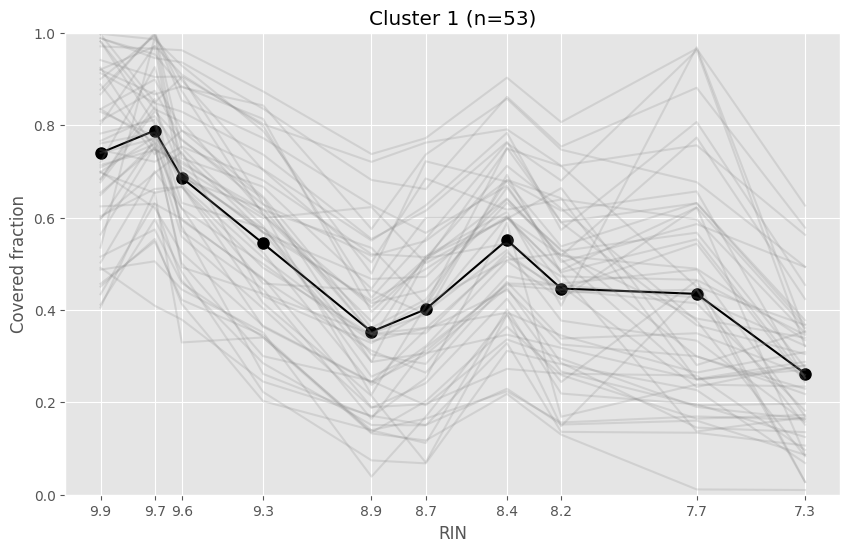

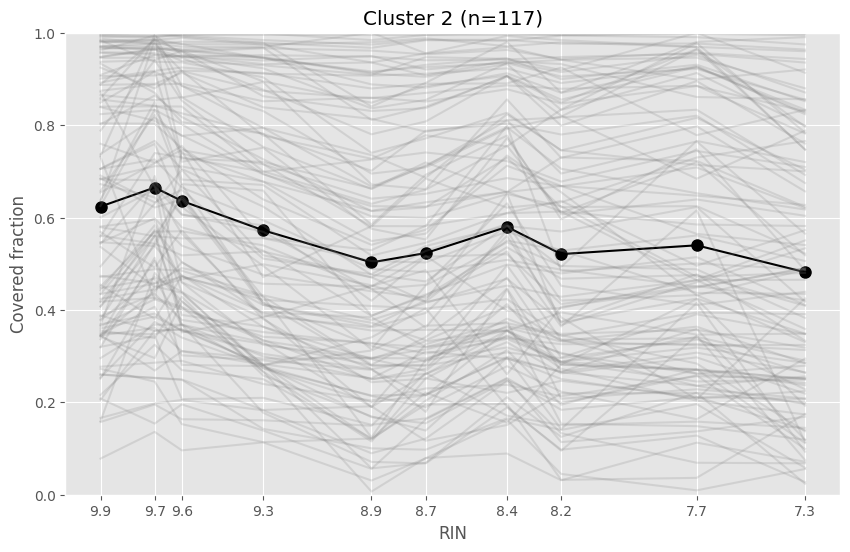

In [349]:


rins = mt5_pivot_kmeans1.iloc[:,1:-1].columns.to_list()
print(rins)
n = -1
print(k)
for i in range(2):
    plt.figure(figsize=(10, 6))
    n += 1
    subset = mt5_pivot_kmeans1[mt5_pivot_kmeans1["cluster"] == i][rins]
    plt.plot(rins, subset.mean(), color = "black", marker="o", markersize=8, label="Media del cluster")
    for i in subset.iterrows():
        plt.plot(rins, i[1], alpha = 0.2, color = "gray")
    plt.title(f"Cluster {n+1} (n={len(subset)})")
    # Ahora quiero poner el eje X al reves, con el RIN más alto a la derecha
    plt.gca().invert_xaxis()
    plt.xlabel("RIN")
    plt.ylabel("Covered fraction")
    plt.xticks(rins)
    plt.ylim(0, 1)
    plt.show()